In [1]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time
import matplotlib.pyplot as plt

import deeplay as dl

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [2]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

Using device: cuda


In [3]:
data = np.load('D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz', allow_pickle=True)

In [4]:
data.keys()

KeysView(NpzFile 'D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz' with keys: E, q, t, n)

In [5]:
index_min = 1300
index_max = 1400

E = data['E'][index_min:index_max]
Q = data['q'][index_min:index_max]
T = data['t'][index_min:index_max] / 2e-7


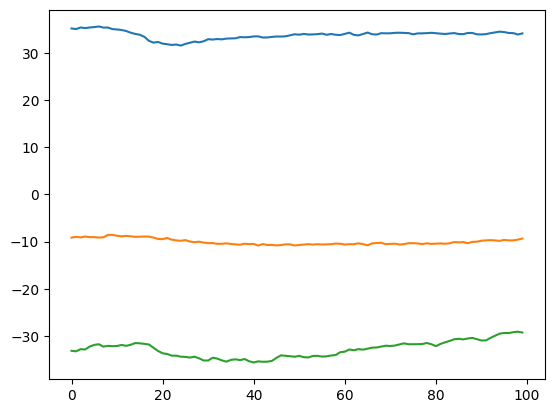

In [6]:
plt.plot(T)

In [7]:
N = data['n']

In [8]:
N.shape

(150, 174, 200)

In [9]:
E.shape

(100, 174, 200)

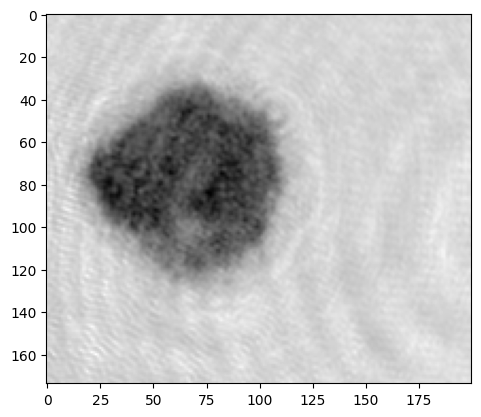

In [10]:
plt.imshow(E[0].real, cmap='gray')


In [11]:
N = torch.tensor(N, dtype=torch.float32, device=DEV)
E = torch.tensor(E, dtype=torch.complex64, device=DEV)
Q = torch.tensor(Q, dtype=torch.float32, device=DEV)
T = torch.tensor(T, dtype=torch.float32, device=DEV)


In [12]:
N = torch.moveaxis(N, 0, 2)  # Move the last dimension to the end

In [13]:
q_new = Q.clone()

q_new[...,1] = Q[...,2]
q_new[...,2] = Q[...,3]
q_new[...,3] = Q[...,1]

In [14]:
t_new = T.clone()

t_new[..., 0] = T[...,0] #0
t_new[..., 1] = T[..., 2]
t_new[..., 2] = T[..., 1]

In [15]:
t_new[0]

tensor([ 35.2159, -33.1507,  -9.1572], device='cuda:0')

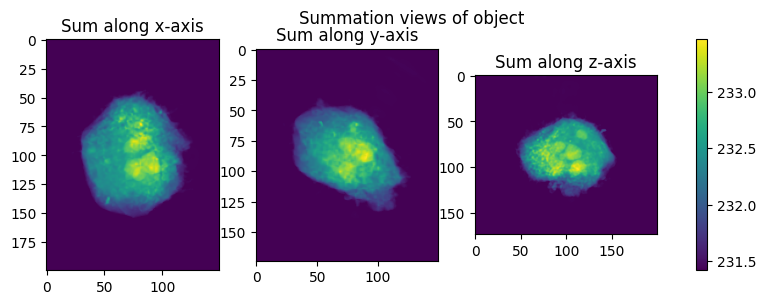

In [16]:
tomodpdt.plotting.plot_sum_object(N.cpu().numpy())

In [17]:
N = N[12:-12, 25:-25]

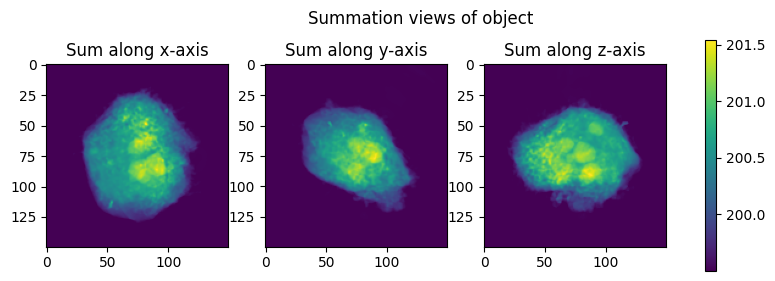

In [18]:
tomodpdt.plotting.plot_sum_object(N.cpu().numpy())

In [19]:
import tomodpdt.forward_module as FM

In [20]:
forward_model = FM.ForwardModelSimple(N=150)

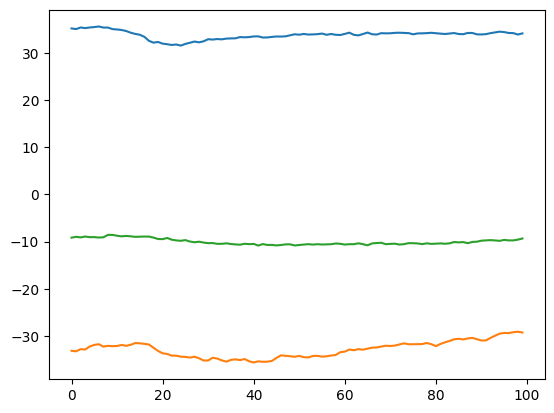

In [21]:
plt.plot(t_new.cpu().numpy())

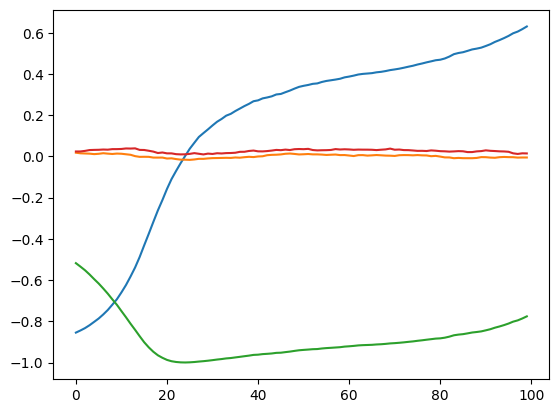

In [22]:
plt.plot(q_new.cpu().numpy())

In [23]:
k=10

In [24]:
#tt = torch.tensor([0, -25, -20]) 

In [25]:
q_new[k]

tensor([-0.6598,  0.0129, -0.7505,  0.0362], device='cuda:0')

In [26]:
t_new[k]

tensor([ 34.9991, -32.1299,  -8.7464], device='cuda:0')

In [27]:
volume_new = forward_model.apply_rotation_translation(volume=N, q=q_new[k], translations=t_new[k])

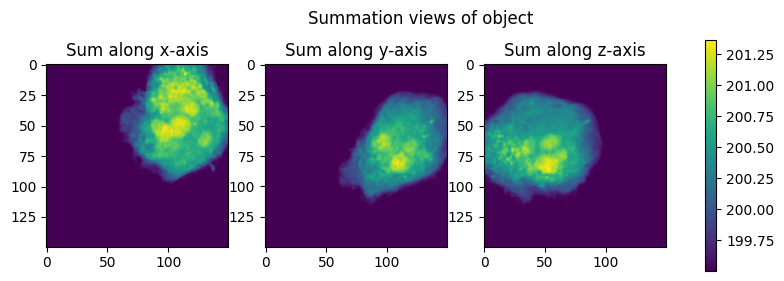

In [28]:
tomodpdt.plotting.plot_sum_object(volume_new.cpu().numpy())

In [29]:
t_new[k]

tensor([ 34.9991, -32.1299,  -8.7464], device='cuda:0')

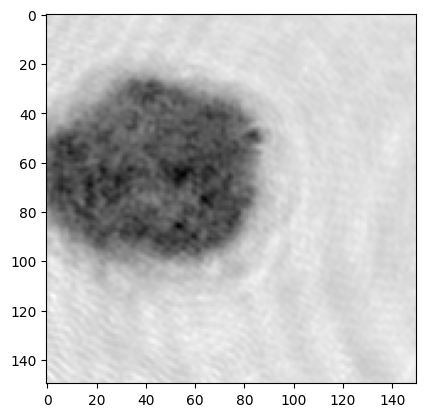

In [30]:
plt.imshow(E[k][12:-12, 25:-25].cpu().real, cmap='gray')

In [31]:
volume = np.load('../test_data/vol_potato1.npy') - 1.33

In [32]:
volume = torch.tensor(volume, dtype=torch.float32, device=DEV)

In [33]:
forward_model = FM.ForwardModelSimple(N=64)

In [34]:
translation = torch.tensor([10, 10, 10], dtype=torch.float32, device=DEV)

In [35]:
k = 20

In [36]:
volume_new = forward_model.apply_rotation_translation(
    volume=volume, 
    q=q_new[k], 
    translations=translation
    )

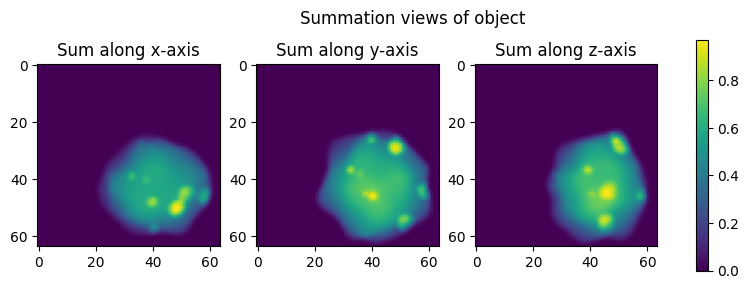

In [37]:
tomodpdt.plotting.plot_sum_object(volume_new.cpu().numpy())

In [38]:
#tomodpdt.plotting.visualize_3d_volume(volume_new.cpu().numpy())